## Tạo Dataset

In [1]:
import json 
from collections import defaultdict

def parse_annotations(json_path):
    with open(json_path, 'r') as f:
        data = json.load(f)

    img_to_anns = defaultdict(list)
    for ann in data['annotations']:
        img_to_anns[ann['image_id']].append({
            'class': ann['class'],
            'bbox': ann['bbox']
        })
    return data['classes'], data['images'], img_to_anns

classes, images_info, train_anns = parse_annotations('/kaggle/input/datasets/nguyenvquanganh/image-object/public/annotations/train.json')
    

In [2]:
import torch
from torch.utils.data import Dataset
import cv2
import os
import albumentations as A
from albumentations.pytorch import ToTensorV2

class ObjectDetectionDataset(Dataset):
    def __init__(self, img_dir, images_info, img_to_anns, classes, transform=None, S=14):
        self.img_dir = img_dir
        self.images_info = images_info
        self.img_to_anns = img_to_anns
        self.classes = classes
        self.class_to_idx = {cls_name: idx for idx, cls_name in enumerate(classes)}
        self.transform = transform
        self.S = S # Kích thước lưới (Grid size)
        self.C = len(classes) # Số lượng class (5)

    def __len__(self):
        return len(self.images_info)

    def __getitem__(self, idx):
        img_info = self.images_info[idx]
        img_path = os.path.join(self.img_dir, img_info['file_name'].split('/')[-1])
        
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        anns = self.img_to_anns[img_info['id']]
        bboxes = [ann['bbox'] for ann in anns]
        labels = [self.class_to_idx[ann['class']] for ann in anns]
        
        if self.transform:
            transformed = self.transform(image=image, bboxes=bboxes, class_labels=labels)
            image = transformed['image']
            bboxes = transformed['bboxes']
            labels = transformed['class_labels']
            
        # ========================================================
        # PHẦN MỚI: TẠO TARGET TENSOR CHO YOLO
        # ========================================================
        # Khởi tạo ma trận toàn số 0. Kích thước: 7 x 7 x (5 class + 1 p_obj + 4 bbox)
        label_matrix = torch.zeros((self.S, self.S, self.C + 5))

        for bbox, class_label in zip(bboxes, labels):
            xmin, ymin, xmax, ymax = bbox
            
            # 1. Tính tâm và kích thước tuyệt đối (pixel)
            x_center = (xmin + xmax) / 2.0
            y_center = (ymin + ymax) / 2.0
            width = xmax - xmin
            height = ymax - ymin
            
            # 2. Chuyển w, h về tỷ lệ [0, 1] so với toàn ảnh (448x448)
            # Do Transform đã resize ảnh về 448 nên ta chia cho 448
            width /= 448.0
            height /= 448.0
            
            # 3. Tìm chỉ số hàng (i) và cột (j) của ô lưới chứa tâm đối tượng
            i = int(self.S * y_center / 448.0)
            j = int(self.S * x_center / 448.0)
            
            # 4. Tính x, y tương đối bên trong ô lưới [0, 1]
            x_cell = (self.S * x_center / 448.0) - j
            y_cell = (self.S * y_center / 448.0) - i
            
            # 5. Gắn vào label_matrix (Chỉ gắn nếu ô đó chưa có đối tượng nào)
            # YOLOv1 mặc định mỗi ô chỉ dự đoán 1 đối tượng
            if label_matrix[i, j, self.C] == 0: 
                # p_obj = 1 (Vị trí số 5)
                label_matrix[i, j, self.C] = 1.0 
                # [x, y, w, h] (Vị trí 6, 7, 8, 9)
                label_matrix[i, j, self.C+1 : self.C+5] = torch.tensor([x_cell, y_cell, width, height])
                # One-hot encoding cho class
                label_matrix[i, j, int(class_label)] = 1.0
                
        return image, label_matrix

In [3]:
# Transform cơ bản: Thay đổi kích thước về 448x448, chuẩn hóa và chuyển thành Tensor
train_transform = A.Compose([
    A.Resize(height=448, width=448),
    A.HorizontalFlip(p=0.5), # Tăng cường dữ liệu (yêu cầu của rubric)
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
], bbox_params=A.BboxParams(format='pascal_voc', label_fields=['class_labels'])) 
# 'pascal_voc' chính là định dạng [xmin, ymin, xmax, ymax] của bạn

In [4]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import torch

def visualize_dataset_sample(dataset, idx=0):
    # 1. Lấy mẫu dữ liệu từ dataset (Chỉ gồm 2 thành phần)
    image, label_matrix = dataset[idx]
    
    # Đưa ảnh từ Tensor (C, H, W) về Numpy (H, W, C) để hiển thị
    if isinstance(image, torch.Tensor):
        image = image.permute(1, 2, 0).numpy()
        # De-normalize đưa về màu gốc
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        image = std * image + mean
        image = np.clip(image, 0, 1)
    else:
        image = image / 255.0

    fig, ax = plt.subplots(1, figsize=(8, 8))
    ax.imshow(image)
    
    S = dataset.S
    C = dataset.C
    classes = dataset.classes

    # 2. Duyệt qua lưới S x S để tìm và giải mã các bounding box
    for i in range(S):       # Hàng
        for j in range(S):   # Cột
            # Kiểm tra xem ô lưới này có chứa tâm đối tượng không (p_obj == 1)
            if label_matrix[i, j, C] == 1.0:
                # Lấy tọa độ tương đối [x_cell, y_cell, width_ratio, height_ratio]
                x_cell, y_cell, w_ratio, h_ratio = label_matrix[i, j, C+1 : C+5]
                
                # Tính toán ngược lại tọa độ tâm tuyệt đối trên ảnh 448x448
                x_center = ((x_cell + j) / S) * 448.0
                y_center = ((y_cell + i) / S) * 448.0
                
                # Tính toán chiều rộng và cao tuyệt đối (pixel)
                width = w_ratio * 448.0
                height = h_ratio * 448.0
                
                # Tính xmin, ymin để vẽ hình chữ nhật trong matplotlib
                xmin = x_center - width / 2.0
                ymin = y_center - height / 2.0
                
                # Vẽ hộp bao lên ảnh
                rect = patches.Rectangle(
                    (xmin, ymin), width, height, 
                    linewidth=2, edgecolor='red', facecolor='none'
                )
                ax.add_patch(rect)
                
                # Lấy class index từ One-hot vector
                class_idx = torch.argmax(label_matrix[i, j, :C]).item()
                class_name = classes[class_idx]
                
                # Thêm nhãn chữ
                ax.text(
                    xmin, ymin - 5, class_name, 
                    color='white', fontsize=12, weight='bold',
                    bbox=dict(facecolor='red', alpha=0.7, edgecolor='none', pad=2)
                )
                
    plt.axis('off')
    plt.show()

Đang vẽ ảnh gốc/lật ngang nghiệm thu...


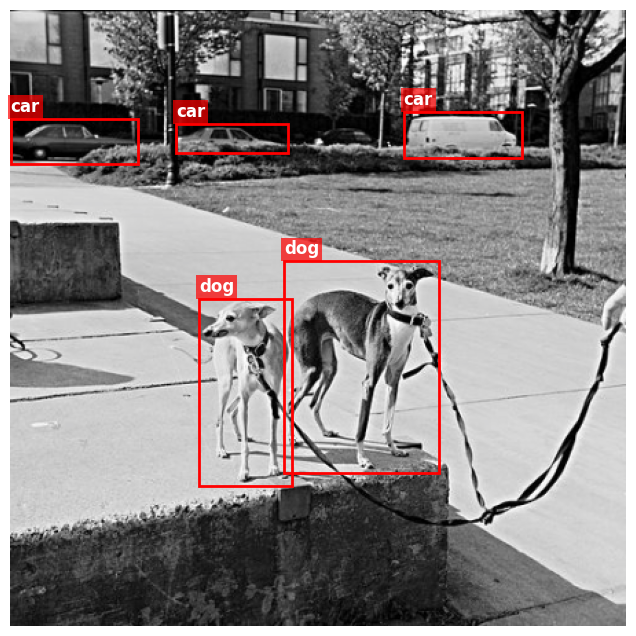

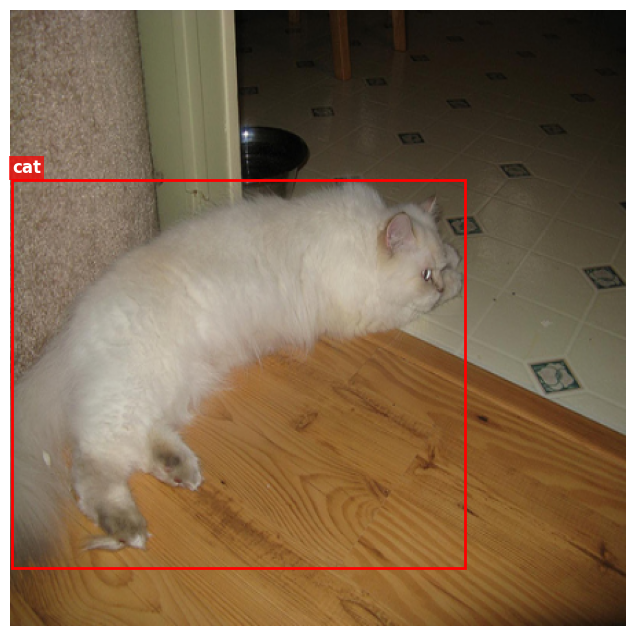

In [5]:
# 1. Khai báo chuỗi biến đổi ảnh (Augmentation)
train_transform = A.Compose([
    A.Resize(height=448, width=448), # Size chuẩn của YOLO
    A.HorizontalFlip(p=0.5),         # Xác suất 50% bị lật ngang
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
], bbox_params=A.BboxParams(format='pascal_voc', label_fields=['class_labels']))

# Đường dẫn (Kiểm tra lại đường dẫn public/annotations/train.json của bạn)
json_path = '/kaggle/input/datasets/nguyenvquanganh/image-object/public/annotations/train.json'
img_dir = '/kaggle/input/datasets/nguyenvquanganh/image-object/public/train/images'

# 2. Đọc file JSON (Dùng hàm parse_annotations bạn vừa viết)
classes, images_info, train_anns = parse_annotations(json_path)

# 3. Khởi tạo Dataset
train_dataset = ObjectDetectionDataset(
    img_dir=img_dir,
    images_info=images_info,
    img_to_anns=train_anns,
    classes=classes,
    transform=train_transform
)

# 4. Trực quan hóa
# Đổi idx để test các ảnh khác nhau
print("Đang vẽ ảnh gốc/lật ngang nghiệm thu...")
visualize_dataset_sample(train_dataset, idx=25)

# Mẹo nhỏ: Gọi lại hàm này vài lần cho CÙNG 1 giá trị `idx`. 
# Vì hàm lật ngang có xác suất 50%, bạn sẽ thấy lúc ảnh bị lật, 
# hộp bao đỏ cũng tự động bám theo đối tượng rất thần kỳ!
visualize_dataset_sample(train_dataset, idx=19)


In [6]:
train_dataset = ObjectDetectionDataset(img_dir, images_info, train_anns, classes, train_transform)
img, target = train_dataset[0]

print("Kích thước ảnh:", img.shape)       # Phải là [3, 448, 448]
print("Kích thước Target:", target.shape) # Phải là [7, 7, 10]

Kích thước ảnh: torch.Size([3, 448, 448])
Kích thước Target: torch.Size([14, 14, 10])


# Kiến trúc mạng

In [7]:
import torch
import torch.nn as nn
import torchvision.models as models

class YoloResNet(nn.Module):
    def __init__(self, num_classes=5, S=14):
        super().__init__()
        self.S = S
        self.C = num_classes
        
        # 1. Tải Backbone ResNet18 (Pretrained)
        resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        
        # Cắt bỏ 2 lớp cuối cùng (AdaptiveAvgPool2d và Linear)
        # Output của self.backbone sẽ có shape: (Batch, 512, 14, 14)
        self.backbone = nn.Sequential(*list(resnet.children())[:-2])
        
        # 2. Xây dựng Detection Head (Mạng chập thay cho Fully Connected)
        self.head = nn.Sequential(
            # Lớp này giảm kích thước không gian từ 14x14 xuống lưới 7x7
            nn.Conv2d(in_channels=512, out_channels=1024, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(1024),
            nn.LeakyReLU(0.1),
            
            # Lớp này nén số kênh (channels) về đúng 10 (5 class + 1 p_obj + 4 bbox)
            nn.Conv2d(in_channels=1024, out_channels=self.C + 5, kernel_size=1, stride=1, padding=0)
        )

    def forward(self, x):
        x = self.backbone(x)           # Shape: (Batch, 512, 14, 14)
        x = self.head(x)               # Shape: (Batch, 10, 7, 7)
        
        # PyTorch Conv2d trả về định dạng (Batch, Channel, Height, Width)
        # Target của ta là (Batch, Height, Width, Channel). Cần dùng permute để đảo trục!
        x = x.permute(0, 2, 3, 1)      # Shape: (Batch, 7, 7, 10)
        
        # Tạo bản sao để tránh lỗi inplace của PyTorch
        out = x.clone()
        
        # Áp dụng Sigmoid cho p_obj và [x, y, w, h] để ép giá trị dự đoán về khoảng [0, 1]
        # Các logits của Class (từ 0 đến 4) ta giữ nguyên để dùng BCEWithLogitsLoss cho ổn định
        out[..., self.C:] = torch.sigmoid(x[..., self.C:])
        
        return out

In [8]:
# Khởi tạo mô hình
model = YoloResNet(num_classes=5, S=7)

# Lấy thử 1 batch dữ liệu từ Dataset (giả sử batch_size = 2)
# Tạo một DataLoader tạm thời để test
from torch.utils.data import DataLoader
train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True)

# Lấy 1 batch
images, targets = next(iter(train_loader))

# Chạy qua mô hình
predictions = model(images)

print("Kích thước ảnh đầu vào (Input):", images.shape)     # Mong đợi: [2, 3, 448, 448]
print("Kích thước dự đoán (Predictions):", predictions.shape) # Mong đợi: [2, 7, 7, 10]
print("Kích thước nhãn thật (Targets):", targets.shape)       # Mong đợi: [2, 7, 7, 10]

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 157MB/s] 


Kích thước ảnh đầu vào (Input): torch.Size([2, 3, 448, 448])
Kích thước dự đoán (Predictions): torch.Size([2, 14, 14, 10])
Kích thước nhãn thật (Targets): torch.Size([2, 14, 14, 10])


# Loss function

In [9]:
import torchvision.ops as ops
import torch.nn.functional as F

class YoloLoss(nn.Module):
    def __init__(self, S=14, C=5):
        super().__init__()
        self.S, self.C = S, C
        self.bce_class = nn.BCEWithLogitsLoss(reduction='none')
        self.lambda_coord, self.lambda_obj, self.lambda_noobj, self.lambda_class = 5.0, 1.0, 0.5, 1.0

    def forward(self, predictions, targets):
        batch_size = predictions.shape[0]
        device = predictions.device
        
        obj_mask = targets[..., self.C] == 1.0     
        noobj_mask = targets[..., self.C] == 0.0

        # 1. GIoU Loss cho Tọa độ
        grid_y, grid_x = torch.meshgrid(torch.arange(self.S, device=device), torch.arange(self.S, device=device), indexing='ij')
        grid_y = grid_y.unsqueeze(0).expand(batch_size, -1, -1)
        grid_x = grid_x.unsqueeze(0).expand(batch_size, -1, -1)
        
        pred_x, pred_y = predictions[..., self.C+1], predictions[..., self.C+2]
        pred_w, pred_h = predictions[..., self.C+3], predictions[..., self.C+4]
        target_x, target_y = targets[..., self.C+1], targets[..., self.C+2]
        target_w, target_h = targets[..., self.C+3], targets[..., self.C+4]
        
        pred_cx, pred_cy = (pred_x + grid_x) / self.S, (pred_y + grid_y) / self.S
        target_cx, target_cy = (target_x + grid_x) / self.S, (target_y + grid_y) / self.S
        
        pred_boxes = torch.stack([pred_cx - pred_w/2, pred_cy - pred_h/2, pred_cx + pred_w/2, pred_cy + pred_h/2], dim=-1)
        target_boxes = torch.stack([target_cx - target_w/2, target_cy - target_h/2, target_cx + target_w/2, target_cy + target_h/2], dim=-1)
        
        pred_boxes_obj = pred_boxes[obj_mask]
        target_boxes_obj = target_boxes[obj_mask]
        
        if len(pred_boxes_obj) > 0:
            giou = ops.generalized_box_iou(pred_boxes_obj, target_boxes_obj)
            box_loss = (1.0 - torch.diag(giou)).sum()
        else:
            box_loss = torch.tensor(0.0, device=device)

        # 2. Focal Loss cho Objectness (Khắc phục mất cân bằng background)
        pred_obj, target_obj = predictions[..., self.C], targets[..., self.C]
        bce = F.binary_cross_entropy(pred_obj, target_obj, reduction='none')
        pt = torch.exp(-bce)
        focal_loss = 0.25 * (1 - pt)**2.0 * bce
        object_loss = focal_loss[obj_mask].sum() * self.lambda_obj + focal_loss[noobj_mask].sum() * self.lambda_noobj

        # 3. Class Loss
        class_preds, class_targets = predictions[..., :self.C][obj_mask], targets[..., :self.C][obj_mask]
        if len(class_preds) > 0:
            class_loss = self.bce_class(class_preds, class_targets).sum() * self.lambda_class
        else:
            class_loss = torch.tensor(0.0, device=device)

        return (self.lambda_coord * box_loss + object_loss + class_loss) / batch_size


In [11]:
# Khởi tạo hàm Loss
criterion = YoloLoss(S=14, C=5)

# Tính Loss thử với dữ liệu từ Sanity Check lúc nãy
loss = criterion(predictions, targets)

print("Giá trị Loss ban đầu (chưa train):", loss.item())

# Test backward (Kiểm tra xem gradient có bị đứt gãy ở đâu không)
loss.backward()
print("Backward thành công! Không bị đứt gãy đồ thị tính toán.")

Giá trị Loss ban đầu (chưa train): 21.927356719970703
Backward thành công! Không bị đứt gãy đồ thị tính toán.


In [12]:
# 1. Cài đặt Device (Sử dụng T4 GPU của Kaggle)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Đang sử dụng device: {device}")


Đang sử dụng device: cuda


In [13]:
import torch.optim as optim
from tqdm import tqdm
import os


# Đưa model và loss function lên GPU
model = model.to(device)
criterion = criterion.to(device)

# 2. Khởi tạo Optimizer
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)

# Tạo thư mục lưu model theo yêu cầu đề bài
os.makedirs('./models', exist_ok=True)

# 3. Vòng lặp huấn luyện (Training Loop)
num_epochs = 50
best_loss = float('inf')

# Khởi tạo DataLoader chính thức (Batch size = 16 hoặc 32 tùy VRAM, T4 dư sức chạy 32)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=2)

print("Bắt đầu huấn luyện...")
for epoch in range(num_epochs):
    model.train() # Chuyển model sang chế độ train
    epoch_loss = 0
    
    # Thanh tiến trình hiển thị cho đẹp
    loop = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{num_epochs}]", leave=True)
    
    for batch_idx, (images, targets) in enumerate(loop):
        # Đẩy dữ liệu lên GPU
        images = images.to(device)
        targets = targets.to(device)
        

        optimizer.zero_grad()
        
        # 2. Forward (Dự đoán)
        predictions = model(images)
        
        # 3. Tính Loss
        loss = criterion(predictions, targets)
        
        # 4. Backward (Tính gradient mới)
        loss.backward()
        
        # 5. Cập nhật trọng số
        optimizer.step()
        # ---------------------------------
        
        epoch_loss += loss.item()
        
        # Cập nhật thanh tiến trình
        loop.set_postfix(loss=loss.item())
        
    # Tính loss trung bình của epoch
    avg_loss = epoch_loss / len(train_loader)
    print(f"-> Trung bình Loss Epoch {epoch+1}: {avg_loss:.4f}")
    
    # Lưu model tốt nhất
    if avg_loss < best_loss:
        best_loss = avg_loss
        torch.save(model.state_dict(), './models/model1.pth')
        print("   [!] Đã lưu checkpoint mới tốt nhất vào ./models/best.pth")

Bắt đầu huấn luyện...


Epoch [1/50]: 100%|██████████| 469/469 [01:47<00:00,  4.35it/s, loss=6.41]


-> Trung bình Loss Epoch 1: 4.9998
   [!] Đã lưu checkpoint mới tốt nhất vào ./models/best.pth


Epoch [2/50]: 100%|██████████| 469/469 [01:41<00:00,  4.61it/s, loss=3.05]


-> Trung bình Loss Epoch 2: 3.7843
   [!] Đã lưu checkpoint mới tốt nhất vào ./models/best.pth


...

-> Trung bình Loss Epoch 48: 0.9400
   [!] Đã lưu checkpoint mới tốt nhất vào ./models/best.pth


Epoch [49/50]: 100%|██████████| 469/469 [01:41<00:00,  4.61it/s, loss=0.231]


-> Trung bình Loss Epoch 49: 0.9225
   [!] Đã lưu checkpoint mới tốt nhất vào ./models/best.pth


Epoch [50/50]: 100%|██████████| 469/469 [01:41<00:00,  4.61it/s, loss=0.453]

-> Trung bình Loss Epoch 50: 0.9100
   [!] Đã lưu checkpoint mới tốt nhất vào ./models/best.pth


Predictions trên ảnh này: 0 box, max objectness = 0.1024


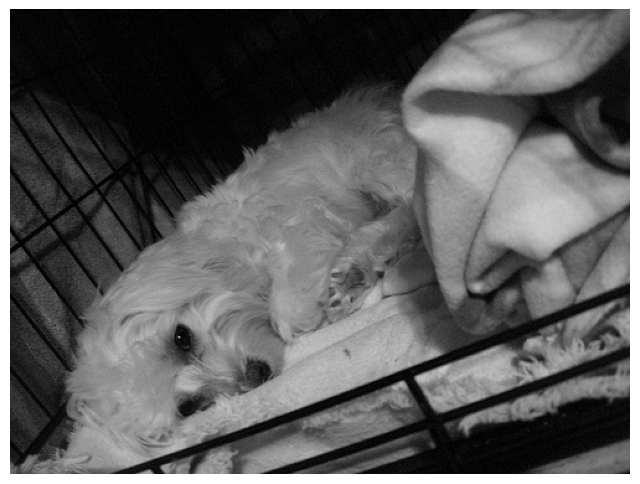

In [14]:
import torch
import cv2
import numpy as np
import torchvision.ops as ops
import matplotlib.pyplot as plt


def predict_image(model, image_path, threshold=0.15, iou_threshold=0.4):
    model.eval()

    # 1. Tiền xử lý ảnh
    original_img = cv2.imread(image_path)
    original_img = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(original_img, (448, 448))

    # Normalize (giống hệt lúc train)
    img_tensor = (img_resized / 255.0 - np.array([0.485, 0.456, 0.406])) / np.array([0.229, 0.224, 0.225])
    img_tensor = torch.tensor(img_tensor).permute(2, 0, 1).unsqueeze(0).float().to(device)

    # 2. Dự đoán
    with torch.no_grad():
        predictions = model(img_tensor)  # Shape: (1, 7, 7, 10)

    # 3. Giải mã thành list các hộp bao
    boxes = []
    max_obj = 0.0
    for i in range(7):
        for j in range(7):
            obj_score = predictions[0, i, j, 5].item()
            max_obj = max(max_obj, obj_score)

            if obj_score < threshold:
                continue

            class_probs = torch.softmax(predictions[0, i, j, :5], dim=0)
            class_idx = torch.argmax(class_probs).item()
            class_score = class_probs[class_idx].item()
            final_score = obj_score * class_score

            if final_score < threshold:
                continue

            x, y, w, h = predictions[0, i, j, 6:10]
            x = x.item()
            y = y.item()
            w = w.item()
            h = h.item()

            # Tọa độ pixel trên ảnh 448x448
            cx = (j + x) * (448 / 7)
            cy = (i + y) * (448 / 7)
            bw = w * 448
            bh = h * 448

            x1 = max(0, cx - bw / 2)
            y1 = max(0, cy - bh / 2)
            x2 = min(448, cx + bw / 2)
            y2 = min(448, cy + bh / 2)

            boxes.append((x1, y1, x2, y2, final_score, class_idx))

    if len(boxes) == 0:
        print(f"Predictions trên ảnh này: 0 box, max objectness = {max_obj:.4f}")
        return original_img, []

    # 4. NMS để loại box trùng
    box_tensor = torch.tensor([[b[0], b[1], b[2], b[3]] for b in boxes], dtype=torch.float32)
    score_tensor = torch.tensor([b[4] for b in boxes], dtype=torch.float32)
    keep_idx = ops.nms(box_tensor, score_tensor, iou_threshold)
    final_boxes = [boxes[i] for i in keep_idx.tolist()]

    print(f"Predictions trên ảnh này: {len(final_boxes)} box, max objectness = {max_obj:.4f}")
    return original_img, final_boxes


image_path = r'/kaggle/input/datasets/nguyenvquanganh/image-object/public/val/images/img_0129428d3af0.jpg'
img, final_boxes = predict_image(model, image_path)

plt.figure(figsize=(8, 8))
plt.imshow(img)
for box in final_boxes:
    x1, y1, x2, y2, conf, cls = box
    rect = plt.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, color='red', linewidth=2)
    plt.gca().add_patch(rect)

    class_name = classes[int(cls)] if 'classes' in globals() and int(cls) < len(classes) else f'class_{int(cls)}'
    plt.text(
        x1,
        max(0, y1 - 5),
        f'{class_name} {conf:.2f}',
        color='yellow',
        fontsize=8,
        bbox=dict(facecolor='black', alpha=0.5, pad=1)
    )

plt.axis('off')
plt.show()

In [15]:
import json
import os
from collections import defaultdict

import cv2
import torch


def bbox_iou(box_a, box_b):
    ax1, ay1, ax2, ay2 = box_a
    bx1, by1, bx2, by2 = box_b

    inter_x1 = max(ax1, bx1)
    inter_y1 = max(ay1, by1)
    inter_x2 = min(ax2, bx2)
    inter_y2 = min(ay2, by2)

    inter_w = max(0.0, inter_x2 - inter_x1)
    inter_h = max(0.0, inter_y2 - inter_y1)
    intersection = inter_w * inter_h

    area_a = max(0.0, ax2 - ax1) * max(0.0, ay2 - ay1)
    area_b = max(0.0, bx2 - bx1) * max(0.0, by2 - by1)
    union = area_a + area_b - intersection
    if union <= 0:
        return 0.0
    return intersection / union


def compute_ap(recalls, precisions):
    if not recalls:
        return 0.0

    mrec = [0.0] + recalls + [1.0]
    mpre = [0.0] + precisions + [0.0]

    for index in range(len(mpre) - 2, -1, -1):
        mpre[index] = max(mpre[index], mpre[index + 1])

    ap = 0.0
    for index in range(1, len(mrec)):
        if mrec[index] != mrec[index - 1]:
            ap += (mrec[index] - mrec[index - 1]) * mpre[index]
    return ap


def evaluate_map50(ground_truth, predictions, classes, iou_threshold=0.5):
    gt_by_class = {class_name: defaultdict(list) for class_name in classes}
    for annotation in ground_truth["annotations"]:
        gt_by_class[annotation["class"]][annotation["image_id"]].append(
            {"bbox": [float(value) for value in annotation["bbox"]], "matched": False}
        )

    pred_by_class = {class_name: [] for class_name in classes}
    for prediction in predictions:
        for box in prediction["boxes"]:
            pred_by_class[box["class"]].append(
                {
                    "image_id": prediction["image_id"],
                    "class": box["class"],
                    "confidence": float(box["confidence"]),
                    "bbox": [float(value) for value in box["bbox"]],
                }
            )

    per_class = {}
    aps = []
    total_tp = 0
    total_fp = 0
    total_gt = 0

    for class_name in classes:
        class_gt = gt_by_class[class_name]
        num_gt = sum(len(items) for items in class_gt.values())
        class_preds = sorted(pred_by_class[class_name], key=lambda item: item["confidence"], reverse=True)

        tp_flags = []
        fp_flags = []

        for prediction in class_preds:
            candidates = class_gt.get(prediction["image_id"], [])
            best_iou = 0.0
            best_index = -1

            for index, gt in enumerate(candidates):
                if gt["matched"]:
                    continue
                iou = bbox_iou(prediction["bbox"], gt["bbox"])
                if iou > best_iou:
                    best_iou = iou
                    best_index = index

            if best_index >= 0 and best_iou >= iou_threshold:
                candidates[best_index]["matched"] = True
                tp_flags.append(1)
                fp_flags.append(0)
            else:
                tp_flags.append(0)
                fp_flags.append(1)

        cumulative_tp = []
        cumulative_fp = []
        tp_sum = 0
        fp_sum = 0
        for tp, fp in zip(tp_flags, fp_flags):
            tp_sum += tp
            fp_sum += fp
            cumulative_tp.append(tp_sum)
            cumulative_fp.append(fp_sum)

        recalls = [value / num_gt if num_gt else 0.0 for value in cumulative_tp]
        precisions = [tp / max(tp + fp, 1) for tp, fp in zip(cumulative_tp, cumulative_fp)]
        ap = compute_ap(recalls, precisions) if num_gt else 0.0

        if num_gt:
            aps.append(ap)

        total_tp += tp_sum
        total_fp += fp_sum
        total_gt += num_gt

        per_class[class_name] = {
            "ap": round(ap, 6),
            "num_ground_truth": num_gt,
            "num_predictions": len(class_preds),
            "true_positives": tp_sum,
            "false_positives": fp_sum,
            "recall": round(tp_sum / num_gt, 6) if num_gt else 0.0,
            "precision": round(tp_sum / max(tp_sum + fp_sum, 1), 6),
        }

    map_50 = sum(aps) / len(aps) if aps else 0.0
    return {
        "mAP@0.5": round(map_50, 6),
        "iou_threshold": iou_threshold,
        "num_ground_truth_boxes": total_gt,
        "num_predictions": sum(len(item["boxes"]) for item in predictions),
        "micro_precision": round(total_tp / max(total_tp + total_fp, 1), 6),
        "micro_recall": round(total_tp / total_gt, 6) if total_gt else 0.0,
        "per_class": per_class,
    }


def predict_image_for_eval(model, image_path, threshold=0.15, iou_threshold=0.4):
    model.eval()

    original_img = cv2.imread(image_path)
    if original_img is None:
        raise FileNotFoundError(f"Không đọc được ảnh: {image_path}")

    original_img = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)
    orig_h, orig_w = original_img.shape[:2]
    img_resized = cv2.resize(original_img, (448, 448))

    img_tensor = (img_resized / 255.0 - torch.tensor([0.485, 0.456, 0.406]).numpy()) / torch.tensor([0.229, 0.224, 0.225]).numpy()
    img_tensor = torch.tensor(img_tensor).permute(2, 0, 1).unsqueeze(0).float().to(device)

    with torch.no_grad():
        predictions = model(img_tensor)

    boxes = []
    max_obj = 0.0
    for i in range(14):
        for j in range(14):
            obj_score = predictions[0, i, j, 5].item()
            max_obj = max(max_obj, obj_score)

            if obj_score < threshold:
                continue

            class_probs = torch.softmax(predictions[0, i, j, :5], dim=0)
            class_idx = torch.argmax(class_probs).item()
            class_score = class_probs[class_idx].item()
            final_score = obj_score * class_score

            if final_score < threshold:
                continue

            x, y, w, h = predictions[0, i, j, 6:10]
            cx = (j + x.item()) * (448 / 14.0)
            cy = (i + y.item()) * (448 / 14.0)
            bw = w.item() * 448
            bh = h.item() * 448

            x1 = max(0.0, cx - bw / 2)
            y1 = max(0.0, cy - bh / 2)
            x2 = min(448.0, cx + bw / 2)
            y2 = min(448.0, cy + bh / 2)

            x1 = x1 * orig_w / 448.0
            y1 = y1 * orig_h / 448.0
            x2 = x2 * orig_w / 448.0
            y2 = y2 * orig_h / 448.0

            boxes.append((x1, y1, x2, y2, final_score, class_idx))

    if len(boxes) == 0:
        return original_img, [], max_obj

    box_tensor = torch.tensor([[b[0], b[1], b[2], b[3]] for b in boxes], dtype=torch.float32)
    score_tensor = torch.tensor([b[4] for b in boxes], dtype=torch.float32)
    keep_idx = torch.ops.torchvision.nms(box_tensor, score_tensor, iou_threshold)
    final_boxes = [boxes[i] for i in keep_idx.tolist()]

    return original_img, final_boxes, max_obj


def build_predictions_for_split(model, gt_json_path, image_dir, threshold=0.15, iou_threshold=0.4, max_detections_per_image=100):
    with open(gt_json_path, "r", encoding="utf-8") as file:
        ground_truth = json.load(file)

    classes = ground_truth["classes"]
    predictions = []

    for image_info in ground_truth["images"]:
        image_path = os.path.join(image_dir, os.path.basename(image_info["file_name"]))
        _, boxes, max_obj = predict_image_for_eval(
            model,
            image_path,
            threshold=threshold,
            iou_threshold=iou_threshold,
        )

        boxes = sorted(boxes, key=lambda item: item[4], reverse=True)[:max_detections_per_image]
        image_predictions = []
        for x1, y1, x2, y2, confidence, class_idx in boxes:
            class_idx = int(class_idx)
            image_predictions.append(
                {
                    "class": classes[class_idx],
                    "confidence": float(confidence),
                    "bbox": [float(x1), float(y1), float(x2), float(y2)],
                }
            )

        predictions.append({"image_id": image_info["id"], "boxes": image_predictions})
        print(f'{image_info["id"]}: {len(image_predictions)} boxes, max objectness = {max_obj:.4f}')

    return ground_truth, predictions


def evaluate_model_map(model, gt_json_path, image_dir, threshold=0.15, iou_threshold=0.5, max_detections_per_image=100, output_path=None):
    ground_truth, predictions = build_predictions_for_split(
        model=model,
        gt_json_path=gt_json_path,
        image_dir=image_dir,
        threshold=threshold,
        iou_threshold=iou_threshold,
        max_detections_per_image=max_detections_per_image,
    )

    result = evaluate_map50(
        ground_truth=ground_truth,
        predictions=predictions,
        classes=ground_truth["classes"],
        iou_threshold=iou_threshold,
    )

    print(json.dumps(result, ensure_ascii=False, indent=2))

    if output_path is not None:
        with open(output_path, "w", encoding="utf-8") as file:
            json.dump(result, file, ensure_ascii=False, indent=2)

    return result, predictions


# Ví dụ đánh giá trên tập validation có nhãn
val_json_path = r"/kaggle/input/datasets/nguyenvquanganh/image-object/public/annotations/val.json"
val_image_dir = r"/kaggle/input/datasets/nguyenvquanganh/image-object/public/val/images"

# Nếu muốn lưu kết quả ra file JSON, truyền thêm output_path=r"D:\final_public\val_score.json"
val_result, val_predictions = evaluate_model_map(
    model=model,
    gt_json_path=val_json_path,
    image_dir=val_image_dir,
    threshold=0.15,
    iou_threshold=0.5,
    max_detections_per_image=100,
)


img_00090df9158f.jpg: 1 boxes, max objectness = 0.2199
img_003c3ddc6a82.jpg: 2 boxes, max objectness = 0.3322
img_01073356e41c.jpg: 1 boxes, max objectness = 0.1693
img_010d9636e14e.jpg: 2 boxes, max objectness = 0.2120
img_0129428d3af0.jpg: 0 boxes, max objectness = 0.1180
img_013d9158b9f7.jpg: 3 boxes, max objectness = 0.8573
img_0157c7e7f027.jpg: 0 boxes, max objectness = 0.1394
img_015d7aaa337c.jpg: 0 boxes, max objectness = 0.0574
img_017c2beab91b.jpg: 1 boxes, max objectness = 0.2651
img_01c40aeb6553.jpg: 3 boxes, max objectness = 0.7736
img_01d1b630c028.jpg: 1 boxes, max objectness = 0.1672
img_01d9d5a5b797.jpg: 1 boxes, max objectness = 0.3141
img_01ecd6f1a296.jpg: 1 boxes, max objectness = 0.1814
img_01fe86605ee4.jpg: 4 boxes, max objectness = 0.6907
img_02045d303574.jpg: 2 boxes, max objectness = 0.1948
img_0206e7244c08.jpg: 0 boxes, max objectness = 0.1220
img_0214dbc25497.jpg: 5 boxes, max objectness = 0.9468
img_027ad34a3f39.jpg: 0 boxes, max objectness = 0.1617
img_02de87